In [1]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [2]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

In [3]:
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Embedding dim:', embed.get_sentence_embedding_dimension())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 384


/tmp/ipykernel_3250/3036188270.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Embedding dim:', embed.get_sentence_embedding_dimension())


In [6]:
paragraphs = [
    "Operating Systems: Process management and scheduling algorithms.",
    "Memory management: paging, segmentation, and virtual memory.",
    "File systems: directory structures and file allocation methods.",
    "Synchronization: semaphores, monitors, and critical sections.",
    "Deadlocks: prevention, avoidance, detection, and recovery.",
    "Database Management Systems: ER model and normalization.",
    "SQL: joins, subqueries, views, and triggers.",
    "Transactions: ACID properties and concurrency control.",
    "Indexing: B+ trees and hashing techniques.",
    "Computer Networks: routing algorithms and network layers."
]

print(f'Loaded {len(paragraphs)} paragraphs')

for i, p in enumerate(paragraphs):
    print(f'[{i+1}] {p}')

Loaded 10 paragraphs
[1] Operating Systems: Process management and scheduling algorithms.
[2] Memory management: paging, segmentation, and virtual memory.
[3] File systems: directory structures and file allocation methods.
[4] Synchronization: semaphores, monitors, and critical sections.
[5] Deadlocks: prevention, avoidance, detection, and recovery.
[6] Database Management Systems: ER model and normalization.
[7] SQL: joins, subqueries, views, and triggers.
[8] Transactions: ACID properties and concurrency control.
[9] Indexing: B+ trees and hashing techniques.
[10] Computer Networks: routing algorithms and network layers.


In [7]:
client = PersistentClient(path='./chroma_db')

col = client.get_or_create_collection('hello_syllabus')

# Convert paragraphs into embeddings
vectors = embed.encode(paragraphs).tolist()

# Store inside ChromaDB
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

Indexed 10 documents


In [8]:
queries = [
    'what is dynamic programming?',
    'machine learning topics',
    'operating system processes',
]

for q in queries:

    print(f'\nQuery: {q}')

    # Convert query into embedding
    qv = embed.encode([q]).tolist()

    # Search nearest matches
    results = col.query(
        query_embeddings=qv,
        n_results=3
    )

    docs = results['documents'][0]
    distances = results['distances'][0]

    for j, (d, dist) in enumerate(zip(docs, distances)):

        print(f'[{j+1}] (dist={dist:.3f}) {d}')


Query: what is dynamic programming?
[1] (dist=1.515) Memory management: paging, segmentation, and virtual memory.
[2] (dist=1.524) Operating Systems: Process management and scheduling algorithms.
[3] (dist=1.622) Transactions: ACID properties and concurrency control.

Query: machine learning topics
[1] (dist=1.518) Indexing: B+ trees and hashing techniques.
[2] (dist=1.572) SQL: joins, subqueries, views, and triggers.
[3] (dist=1.621) Memory management: paging, segmentation, and virtual memory.

Query: operating system processes
[1] (dist=0.474) Operating Systems: Process management and scheduling algorithms.
[2] (dist=1.251) Memory management: paging, segmentation, and virtual memory.
[3] (dist=1.282) Transactions: ACID properties and concurrency control.


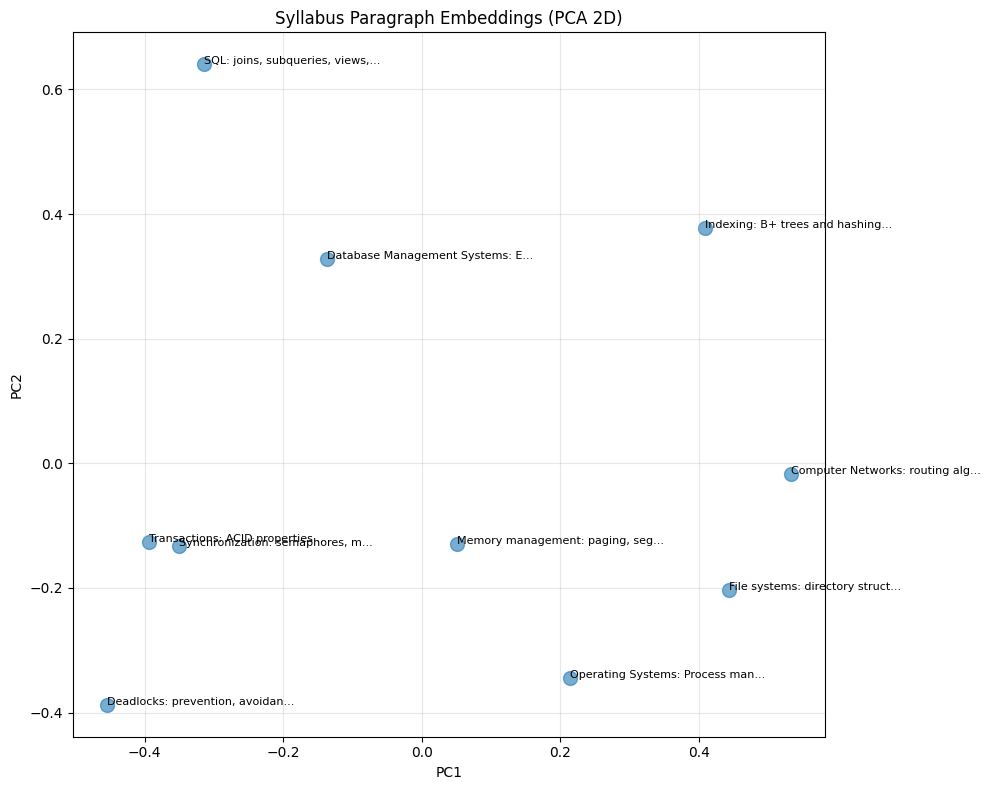

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Convert vectors list into numpy array
vectors_arr = np.array(vectors)

# Reduce dimensions: 384 → 2
pca = PCA(n_components=2)

xy = pca.fit_transform(vectors_arr)

# Create plot
plt.figure(figsize=(10, 8))

plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)

# Add labels
for i, p in enumerate(paragraphs):

    label = p[:30] + '...'

    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

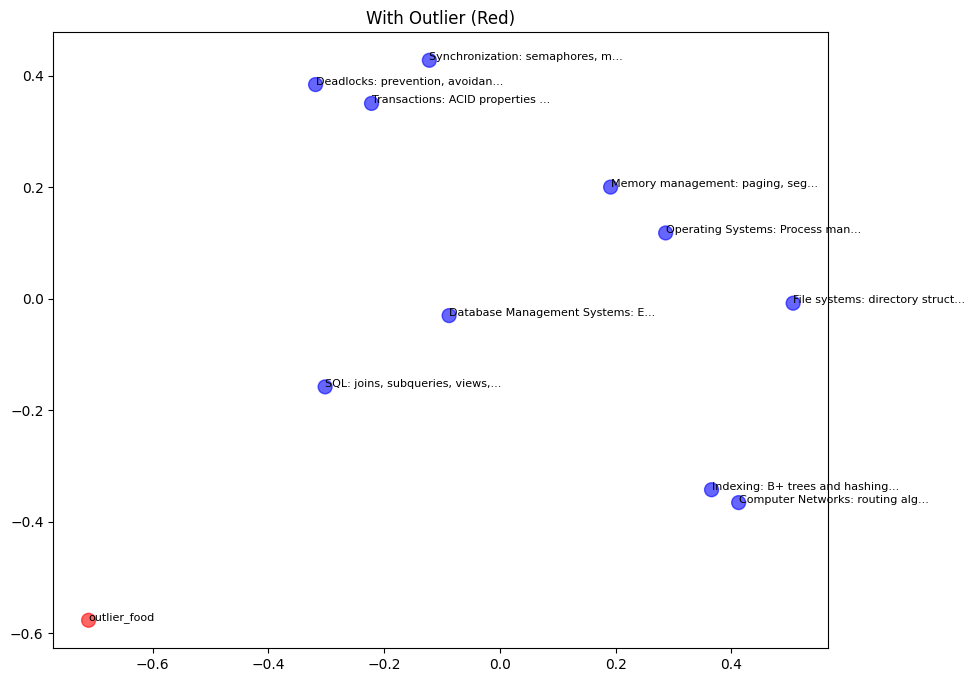

In [10]:
# Add unrelated paragraph
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

# Store it in ChromaDB
col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

# Reload all documents + embeddings
all_docs = col.get(include=['embeddings', 'documents'])

all_vecs = np.array(all_docs['embeddings'])

labels = all_docs['ids']

# PCA again
pca = PCA(n_components=2)

xy = pca.fit_transform(all_vecs)

# Plot
plt.figure(figsize=(10, 8))

colors = ['red' if 'outlier' in l else 'blue' for l in labels]

plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)

# Labels
for i, l in enumerate(labels):

    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'

    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('With Outlier (Red)')

plt.show()